# Adidas Sales Performance Analysis 2025

## Retail Sales Analytics Project Using Python

### Project Type:
Exploratory Data Analysis (EDA) & Business Intelligence

### Tools & Technologies:
- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset Size:
9,649 Rows × 11 Columns

---

## Business Problem

Adidas operates across multiple regions, cities, and sales channels. 
Understanding sales performance, profitability, operating margins, and product trends is essential for making strategic business decisions.

This project analyzes Adidas retail sales data to uncover:

- Best-performing regions and cities
- Most profitable products
- Sales trends across sales methods
- Revenue drivers
- Operating profit patterns
- Business growth opportunities

---

## Project Objectives

The main objectives of this project are:

1. Clean and preprocess the dataset professionally
2. Perform exploratory data analysis (EDA)
3. Identify sales and profit trends
4. Analyze regional and product performance
5. Create professional visualizations
6. Generate actionable business insights
7. Build a portfolio-ready analytics project for GitHub

---

## Expected Outcome

By the end of this project, we will have:

- A clean and analysis-ready dataset
- Professional business visualizations
- Actionable insights from sales data
- A complete portfolio project suitable for GitHub and recruiters

 IMPORTING LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
pd.set_option("display.max_columns",None)

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
sns.set_style('whitegrid')

 LOADING DATASET

In [7]:
df = pd.read_csv("adidas_dataset.csv")

In [8]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,1/1/20,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$600,000","$300,000",50%,In-store
1,Foot Locker,1185732,1/2/20,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$500,000","$150,000",30%,In-store
2,Foot Locker,1185732,1/3/20,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$400,000","$140,000",35%,In-store
3,Foot Locker,1185732,1/4/20,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$382,500","$133,875",35%,In-store
4,Foot Locker,1185732,1/5/20,Northeast,New York,New York,Men's Apparel,$60.00,900,"$540,000","$162,000",30%,In-store


In [9]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns in Dataset:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(9648, 13)

Columns in Dataset:
Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   int64 
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9648 non-null   object
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   ob

In [10]:
misssing_values = df.isnull().sum()

In [11]:
duplicate_rows = df.duplicated().sum()

# Data Cleaning & Preprocessing

In this section, we will clean and prepare the dataset for analysis.

The cleaning process includes:

- Checking data types
- Converting incorrect data types
- Handling missing values
- Removing duplicates
- Standardizing column names
- Formatting numerical columns
- Converting date columns
- Preparing the dataset for analysis and visualization

In [12]:
df.dtypes

Retailer            object
Retailer ID          int64
Invoice Date        object
Region              object
State               object
City                object
Product             object
Price per Unit      object
Units Sold          object
Total Sales         object
Operating Profit    object
Operating Margin    object
Sales Method        object
dtype: object

In [14]:
df['Total Sales'] = (
    df['Total Sales']
    .replace(r'[\$,]', '', regex=True)
    .astype(float))

In [15]:
df['Operating Profit'] = (
    df['Operating Profit']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [16]:
df[['Total Sales','Operating Profit']].dtypes

Total Sales         float64
Operating Profit    float64
dtype: object

In [18]:
df['Operating Margin'] = (
    df['Operating Margin']
    .astype(str)
    .str.replace('%', '')
    .astype(float)
)

In [19]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

In [20]:
df.dtypes

Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Price per Unit              object
Units Sold                  object
Total Sales                float64
Operating Profit           float64
Operating Margin           float64
Sales Method                object
dtype: object

In [21]:
df['Price per Unit'] = (
    df['Price per Unit']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [22]:
df['Units Sold'] = (
    df['Units Sold']
    .replace(r'[,]', '', regex=True)
    .astype(int)
)

In [24]:
df[[
    'Units Sold',
    'Total Sales',
    'Operating Profit',
    'Operating Margin',
    'Price per Unit'
]].dtypes

Units Sold            int64
Total Sales         float64
Operating Profit    float64
Operating Margin    float64
Price per Unit      float64
dtype: object

In [25]:
df.describe()

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.282131,42.299129
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,10.000000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1922.000000,35.000000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.500000,41.000000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52063.000000,49.000000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,80.000000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.124141,9.719742


In [28]:
df.describe().round(2)

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9648.00,9648,9648.00,9648.00,9648.00,9648.00,9648.00
mean,1173849.72,2021-05-10 15:20:44.776119296,45.22,256.93,93273.44,34425.28,42.30
min,1128299.00,2020-01-01 00:00:00,7.00,0.00,0.00,0.00,10.00
25%,1185732.00,2021-02-17 00:00:00,35.00,106.00,4254.50,1922.00,35.00
50%,1185732.00,2021-06-04 00:00:00,45.00,176.00,9576.00,4371.50,41.00
75%,1185732.00,2021-09-16 00:00:00,55.00,350.00,150000.00,52063.00,49.00
max,1197831.00,2021-12-31 00:00:00,110.00,1275.00,825000.00,390000.00,80.00
std,26360.38,NaN,14.71,214.25,141916.02,54193.12,9.72


In [29]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

In [30]:
df.columns

Index(['retailer', 'retailer_id', 'invoice_date', 'region', 'state', 'city',
       'product', 'price_per_unit', 'units_sold', 'total_sales',
       'operating_profit', 'operating_margin', 'sales_method'],
      dtype='object')

In [31]:
missing_values = df.isnull().sum()

In [32]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.round(2)

retailer            0.0
retailer_id         0.0
invoice_date        0.0
region              0.0
state               0.0
city                0.0
product             0.0
price_per_unit      0.0
units_sold          0.0
total_sales         0.0
operating_profit    0.0
operating_margin    0.0
sales_method        0.0
dtype: float64

In [33]:
df = df.dropna()

In [34]:
duplicate_rows = df.duplicated().sum()

In [36]:
df = df.drop_duplicates()

In [37]:
df.shape

(9648, 13)

In [38]:
categorical_columns = [
    'region',
    'state',
    'city',
    'product',
    'sales_method'
]

for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].nunique())


Unique values in region:
5

Unique values in state:
50

Unique values in city:
52

Unique values in product:
6

Unique values in sales_method:
3


In [41]:
df['year'] = df['invoice_date'].dt.year

In [42]:
df['month'] = df['invoice_date'].dt.month

In [44]:
df['month_name'] = df['invoice_date'].dt.month_name()

In [45]:
df['profit_ratio'] = df['operating_profit']/df['total_sales']*100

In [47]:
df.head()

,retailer,retailer_id,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,operating_margin,sales_method,year,month,month_name,profit_ratio
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,50.0,In-store,2020,1,January,50.0
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,30.0,In-store,2020,1,January,30.0
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,35.0,In-store,2020,1,January,35.0
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,35.0,In-store,2020,1,January,35.0
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,30.0,In-store,2020,1,January,30.0


# Exploratory Data Analysis (EDA)

In this section, we analyze Adidas sales performance to uncover business insights, profitability trends, customer purchasing patterns, and regional performance.

The analysis focuses on:

- Revenue performance
- Profitability analysis
- Product trends
- Regional sales performance
- Monthly sales trends
- Sales method effectiveness
- Business opportunities and insights

In [48]:
total_revenue = df['total_sales'].sum()
total_profit = df['operating_profit'].sum()
total_units = df['units_sold'].sum()
average_margin = df['operating_margin'].mean()

print("========== BUSINESS KPIs ==========")

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Operating Profit: ${total_profit:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Operating Margin: {average_margin:.2f}%")

========== BUSINESS KPIs ==========
Total Revenue: $899,902,125.00
Total Operating Profit: $332,135,122.00
Total Units Sold: 2,478,861
Average Operating Margin: 42.30%


In [50]:
region_sales = (
    df.groupby('region')['total_sales']
    .sum()
    .sort_values(ascending=False)
)
region_sales = region_sales.apply(
    lambda x: f"${x:,.0f}"
)

region_sales

region
West         $269,943,182
Northeast    $186,324,067
Southeast    $163,171,236
South        $144,663,181
Midwest      $135,800,459
Name: total_sales, dtype: object

In [51]:
region_profit = (
    df.groupby('region')['operating_profit']
    .sum()
    .sort_values(ascending=False)
)

region_profit = region_profit.apply(
    lambda x: f"${x:,.0f}"
)

region_profit

region
West         $89,609,516
Northeast    $68,020,688
South        $61,138,044
Southeast    $60,555,462
Midwest      $52,811,412
Name: operating_profit, dtype: object

In [52]:
top_products = (
    df.groupby('product')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

top_products = top_products.apply(
    lambda x: f"${x:,.0f}"
)

top_products

product
Men's Street Footwear        $208,826,244
Women's Apparel              $179,038,860
Men's Athletic Footwear      $153,673,680
Women's Street Footwear      $128,002,813
Men's Apparel                $123,728,632
Women's Athletic Footwear    $106,631,896
Name: total_sales, dtype: object

In [53]:
top_profit_products = (
    df.groupby('product')['operating_profit']
    .sum()
    .sort_values(ascending=False)
)

top_profit_products = top_profit_products.apply(
    lambda x: f"${x:,.0f}"
)

top_profit_products

product
Men's Street Footwear        $82,802,323
Women's Apparel              $68,650,996
Men's Athletic Footwear      $51,846,964
Women's Street Footwear      $45,095,897
Men's Apparel                $44,763,099
Women's Athletic Footwear    $38,975,843
Name: operating_profit, dtype: object

In [54]:
sales_method_analysis = (
    df.groupby('sales_method')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

sales_method_analysis = sales_method_analysis.apply(
    lambda x: f"${x:,.0f}"
)

sales_method_analysis

sales_method
In-store    $356,643,750
Outlet      $295,585,493
Online      $247,672,882
Name: total_sales, dtype: object

In [55]:
top_cities = (
    df.groupby('city')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cities = top_cities.apply(
    lambda x: f"${x:,.0f}"
)

top_cities

city
Charleston       $39,974,797
New York         $39,801,235
San Francisco    $34,539,220
Miami            $31,600,863
Portland         $30,545,652
Orlando          $27,682,851
Seattle          $26,330,718
Los Angeles      $25,634,913
Houston          $25,456,882
Albany           $24,427,804
Name: total_sales, dtype: object

In [56]:
monthly_sales = (
    df.groupby('month_name')['total_sales']
    .sum()
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales = monthly_sales.apply(
    lambda x: f"${x:,.0f}"
)

monthly_sales

month_name
January      $71,479,142
February     $61,100,153
March        $56,809,109
April        $72,339,970
May          $80,507,695
June         $74,747,372
July         $95,480,694
August       $92,166,201
September    $77,661,459
October      $63,911,033
November     $67,857,340
December     $85,841,957
Name: total_sales, dtype: object

In [57]:
monthly_profit = (
    df.groupby('month_name')['operating_profit']
    .sum()
)

monthly_profit = monthly_profit.reindex(month_order)

monthly_profit = monthly_profit.apply(
    lambda x: f"${x:,.0f}"
)

monthly_profit

month_name
January      $25,141,970
February     $21,392,765
March        $20,439,808
April        $27,559,278
May          $29,946,287
June         $26,714,734
July         $34,054,930
August       $34,451,469
September    $31,009,630
October      $25,078,465
November     $24,755,550
December     $31,590,236
Name: operating_profit, dtype: object

# Data Visualization

This section presents visual representations of Adidas sales performance using professional business charts and trend analysis.

The visualizations help identify:

- Revenue patterns
- Regional performance
- Product trends
- Profitability insights
- Seasonal sales behavior
- Business opportunities

In [58]:
plt.rcParams['figure.figsize'] = (12, 6)

sns.set_style("whitegrid")

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

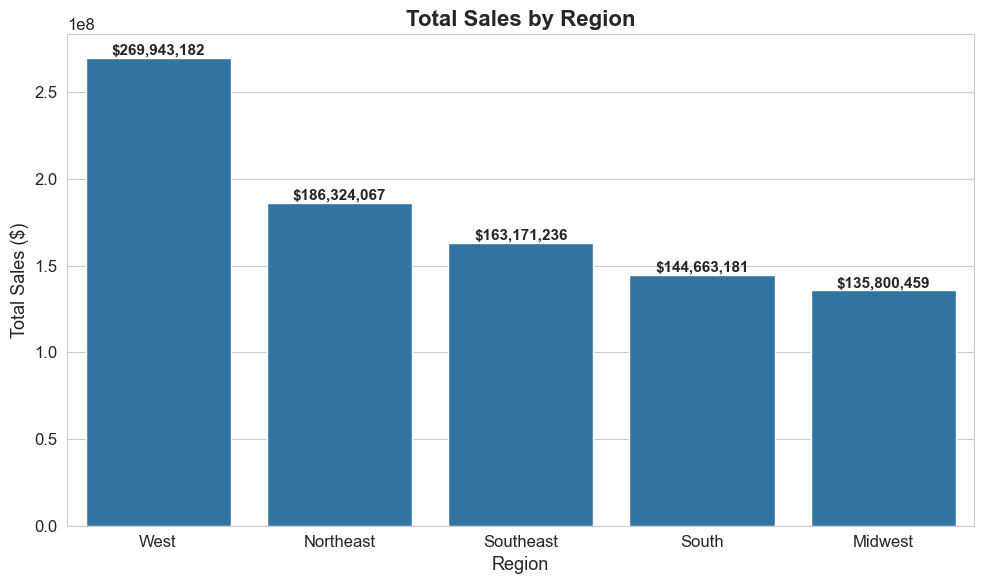

In [59]:
region_sales = (
    df.groupby('region')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Total Sales by Region", fontsize=16, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

### Business Insight — Total Sales by Region

- One or two regions clearly dominate total revenue generation.
- This indicates stronger market demand, better distribution networks, or stronger brand presence in those regions.
- Lower-performing regions represent potential growth opportunities.
- The company can increase revenue by improving marketing and retail expansion in weaker regions.

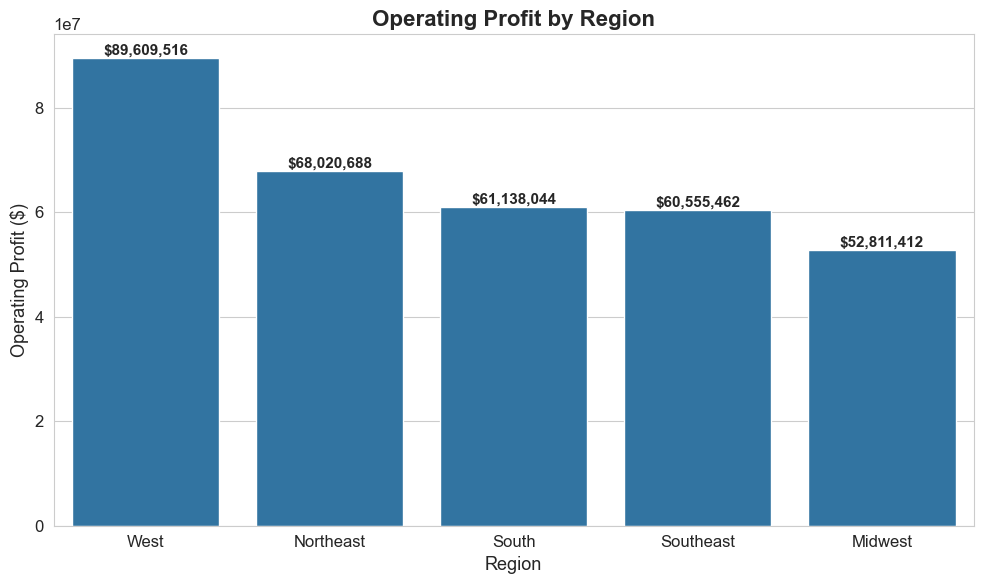

In [60]:
region_profit = (
    df.groupby('region')['operating_profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Operating Profit by Region", fontsize=16, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Operating Profit ($)")

plt.tight_layout()
plt.show()

### Business Insight — Operating Profit by Region

- Profit distribution across regions is not always proportional to sales.
- Some regions generate high revenue but lower profit margins.
- This indicates differences in operational costs, discounts, or pricing strategies.
- The company should focus on improving profitability in underperforming regions rather than only increasing sales.

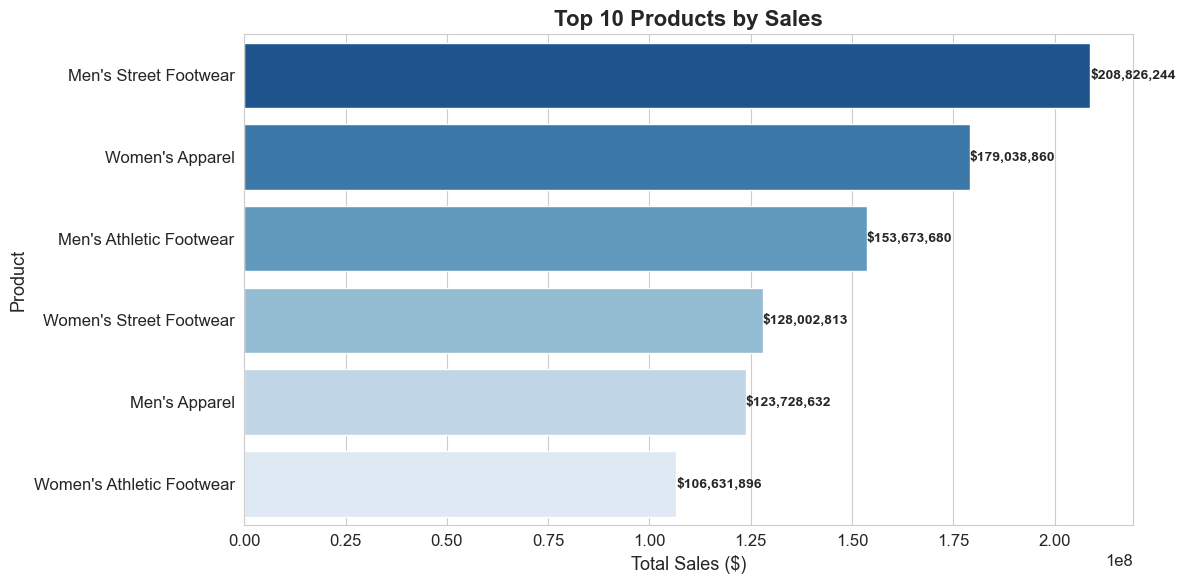

In [61]:
top_products = (
    df.groupby('product')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

colors = sns.color_palette("Blues_r", len(top_products))

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f"${p.get_width():,.0f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Top 10 Products by Sales", fontsize=16, fontweight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Business Insight — Top 10 Products by Sales

- A small group of products contributes significantly to overall revenue, showing a clear **concentration of demand**.
- The top-performing products can be considered the company’s **core revenue drivers** and should be prioritized in inventory planning and marketing campaigns.
- Lower-ranked products within the top 10 still contribute meaningfully, but the gap between the top few and the rest suggests **uneven product performance distribution**.
- This indicates an opportunity for Adidas to:
  - Strengthen promotion of mid-performing products  
  - Analyze what makes top products successful (pricing, demand, category)  
  - Optimize product portfolio to maximize overall revenue
- Overall, the product sales pattern follows a **Pareto-like distribution (80/20 behavior)** where a few products generate most of the revenue.

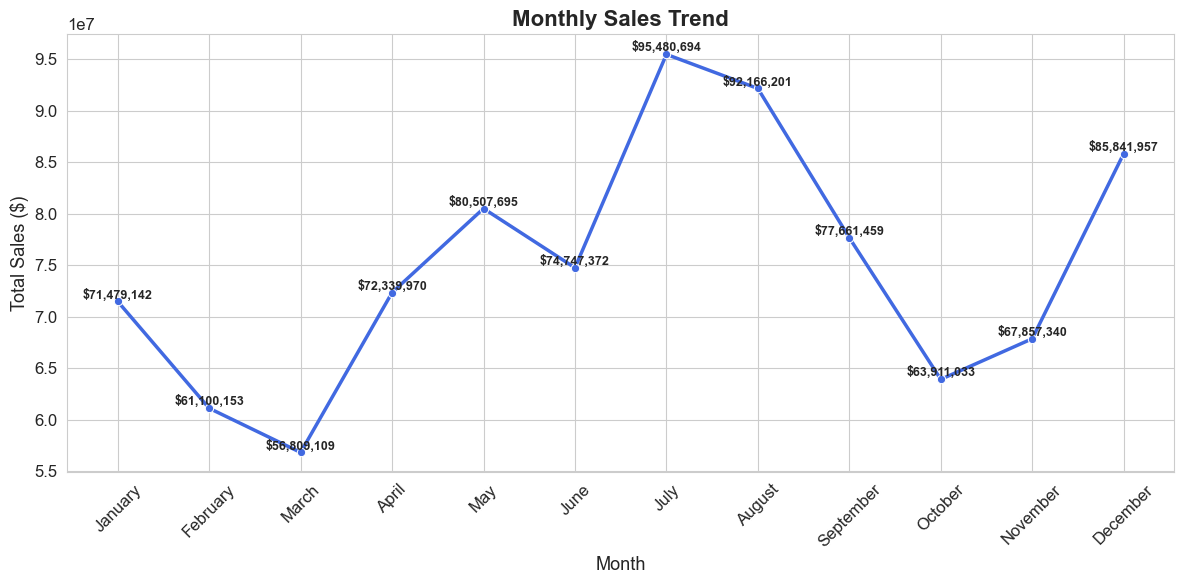

In [62]:
monthly_sales = (
    df.groupby('month_name')['total_sales']
    .sum()
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o',
    linewidth=2.5,
    color='royalblue'
)

for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(
        x, y,
        f"${y:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title("Monthly Sales Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight — Monthly Sales Trend

- Sales performance fluctuates across the year, indicating **seasonal demand patterns**.
- Certain months show significantly higher sales, which may be linked to:
  - Holiday seasons
  - Marketing campaigns
  - Product launches
- Lower-performing months suggest periods where demand slows down, which can be targeted with promotions or discounts.
- Understanding this trend helps Adidas:
  - Improve inventory planning
  - Optimize marketing budgets
  - Increase revenue during low-demand months

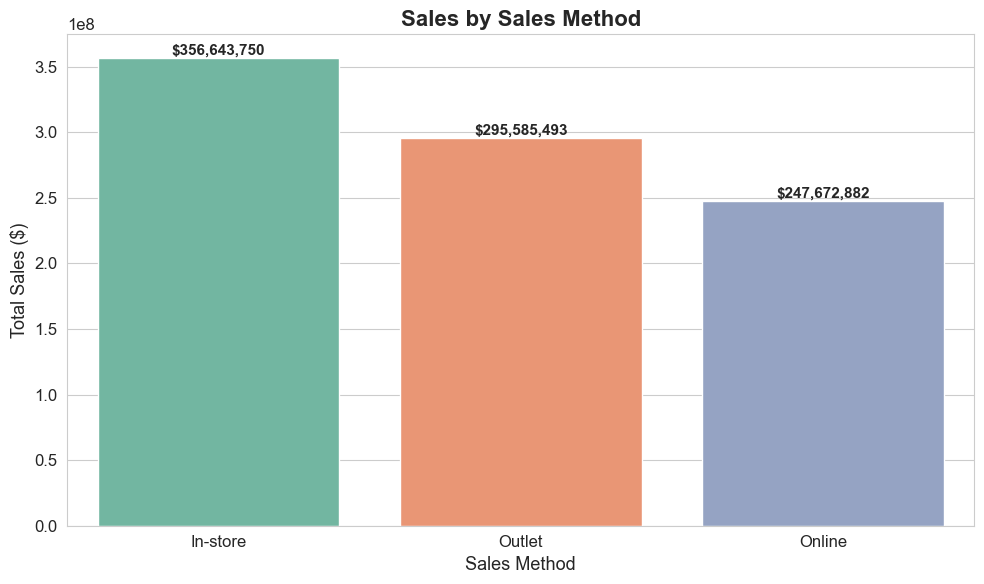

In [63]:
sales_method = (
    df.groupby('sales_method')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

colors = sns.color_palette("Set2", len(sales_method))

ax = sns.barplot(
    x=sales_method.index,
    y=sales_method.values,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Sales by Sales Method", fontsize=16, fontweight='bold')
plt.xlabel("Sales Method")
plt.ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

### Business Insight — Sales Method Performance

- Sales performance varies significantly across different sales channels.
- One channel clearly dominates, showing it is the **primary revenue driver** for Adidas.
- Lower-performing channels still contribute but may require:
  - Better marketing strategies
  - Improved customer experience
  - More digital transformation (if online is weaker)
- Understanding channel performance helps Adidas:
  - Allocate marketing budget effectively
  - Improve underperforming channels
  - Strengthen the most profitable sales method

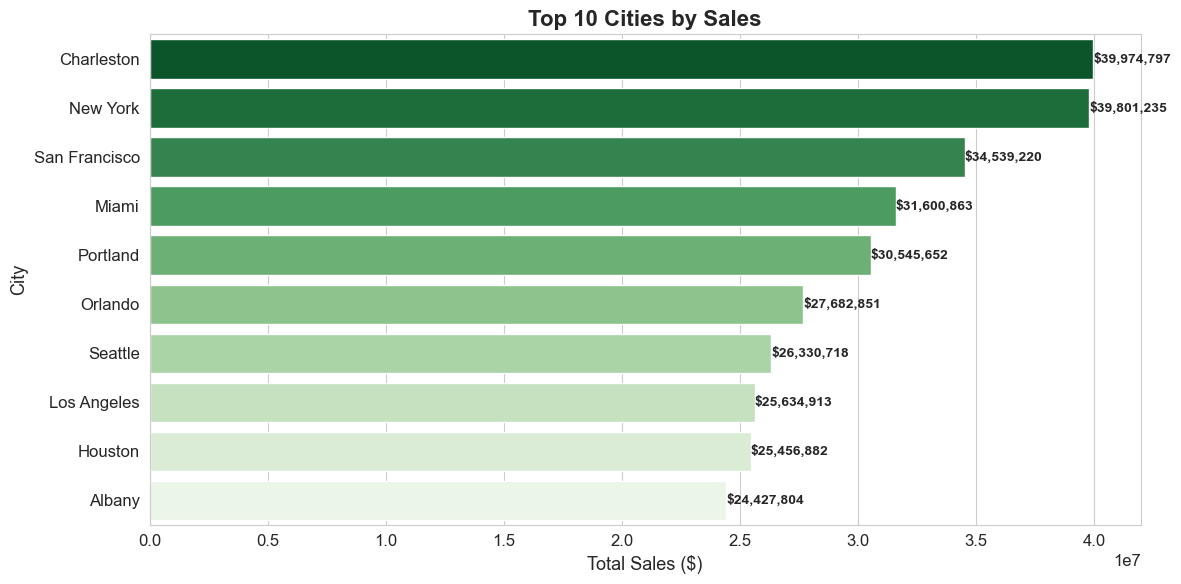

In [64]:
top_cities = (
    df.groupby('city')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

colors = sns.color_palette("Greens_r", len(top_cities))

ax = sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    palette=colors
)

for p in ax.patches:
    ax.annotate(
        f"${p.get_width():,.0f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Top 10 Cities by Sales", fontsize=16, fontweight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Business Insight — Top Cities by Sales

- Sales are highly concentrated in a few major cities, indicating strong urban market dominance.
- These top-performing cities likely have:
  - Higher customer demand
  - Better retail infrastructure
  - Stronger brand presence
- Cities outside the top 10 represent **growth opportunities** for expansion.
- Adidas can improve performance in lower-ranked cities by:
  - Increasing local marketing campaigns
  - Expanding retail distribution
  - Enhancing online availability and delivery speed
- This geographic insight helps in **strategic expansion planning** and resource allocation.

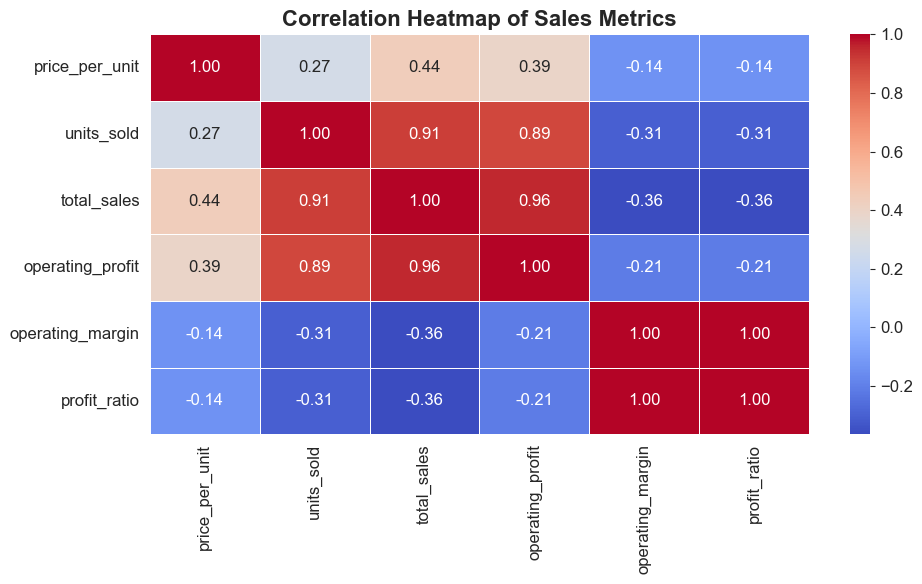

In [65]:
numeric_df = df[[
    'price_per_unit',
    'units_sold',
    'total_sales',
    'operating_profit',
    'operating_margin',
    'profit_ratio'
]]

corr = numeric_df.corr()

plt.figure(figsize=(10,6))

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Sales Metrics", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Business Insight — Correlation Analysis

- There is a strong positive relationship between:
  - Total Sales and Operating Profit
  - Units Sold and Total Sales

- This indicates that higher sales volume directly contributes to higher profitability.

- Price per Unit may show weaker or mixed correlation with sales, suggesting that:
  - Demand is more volume-driven than price-driven in some cases.

- Operating Margin and Profit Ratio help evaluate efficiency rather than scale.

- Overall, the business is driven mainly by:
  - Sales volume
  - Product demand

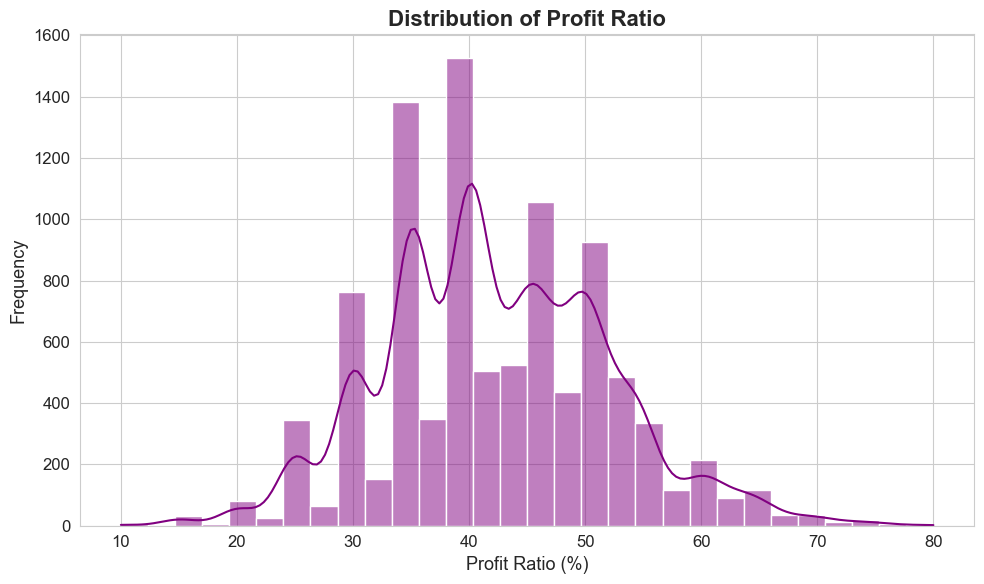

In [66]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    df['profit_ratio'],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Profit Ratio", fontsize=16, fontweight='bold')
plt.xlabel("Profit Ratio (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Business Insight — Profit Ratio Distribution

- The profit ratio distribution shows how efficiently sales are converted into profit.
- A concentrated distribution indicates stable profitability across transactions.
- Wider variation suggests inconsistency in pricing strategy or cost structure.
- Lower profit ratio transactions may be impacted by:
  - Discounts
  - High operational costs
  - Low-margin product categories

- This insight helps Adidas:
  - Improve pricing strategy
  - Optimize cost structure
  - Focus on high-margin products

# Final Business Report & Conclusions

This section summarizes the key findings from the Adidas sales analysis and provides actionable business recommendations.

The goal is to transform data insights into strategic decisions.

## Executive Summary

The analysis of Adidas sales data reveals strong overall business performance with clear variations across regions, products, and sales channels.

Key highlights include:
- Strong revenue concentration in specific regions and cities
- A small group of products driving the majority of sales
- Seasonal fluctuations in monthly sales performance
- Clear differences in profitability across regions and products
- Significant impact of sales methods on total revenue generation

## Key Findings

- Certain regions significantly outperform others in both sales and profit.
- Product performance follows a Pareto distribution (few products generate most revenue).
- Sales show clear seasonal trends across the year.
- Online/retail/outlet channels contribute differently to revenue.
- Profitability is not always aligned with total sales volume.
- Some cities act as major revenue hubs for Adidas.

## Business Recommendations

- Focus marketing and expansion efforts on top-performing regions and cities.
- Optimize underperforming regions with targeted campaigns and improved distribution.
- Increase investment in high-performing products while reviewing low-margin items.
- Strengthen the most profitable sales channels (online or retail depending on performance).
- Use seasonal trends to plan inventory and marketing campaigns more effectively.
- Improve pricing and cost structure to increase overall profit margins.

## Final Conclusion

This analysis demonstrates that Adidas has strong market performance driven by specific regions, products, and sales channels.

However, there are clear opportunities for optimization in:
- Regional expansion strategy
- Product portfolio management
- Sales channel optimization
- Profit margin improvement

By leveraging these insights, Adidas can improve revenue efficiency, maximize profitability, and strengthen its competitive position in the market.